# Enhancer hijacking — RNA-seq (N-padded frame)

Identical pipeline to `tss_centered/rna_seq_analysis.ipynb`, run on the **N-padded** frame (`n_padded_TSS_centered_data.csv`) — distal context masked to N. `tss_centered` here holds the N-padded df.

In [1]:
import os
import pandas as pd

pd.set_option('display.max_columns', None)

DATA = next(d for d in ('data', '../data', 'v2/data', '../v2/data', '../../data') if os.path.isdir(d))

tss_centered = pd.read_csv(f'{DATA}/n_padded_TSS_centered_data.csv')
junction     = pd.read_csv(f'{DATA}/event_site_centered_data.csv')
npad         = pd.read_csv(f'{DATA}/n_padded_TSS_centered_data.csv')

{name: df.shape for name, df in
 (('tss_centered', tss_centered), ('junction', junction), ('npad', npad))}

{'tss_centered': (8, 22), 'junction': (5, 25), 'npad': (8, 22)}

In [2]:
tss_centered.drop(columns=['wt_seq', 'der_seq'])

,name,type,mechanism,driven_gene,onco_chrom,onco_tss,strand,enhancer,enh_chrom,enh_start,enh_end,element_len,element_note,insert_kb_from_TSS,ontology,cell_context,seq_len,core_kb,kept_bp,n_pad_frac
0,GATA2-MECOM,positive,enhancer_hijacking,EVI1 (MECOM),chr3,169146305.0,-,G2DHE (GATA2 distal enhancer),chr3,128603548.0,128604548.0,1000.0,NaN,10.0,EFO:0002067,"K562 (GATA2+, EVI1-silent)",1048576,64,128000,0.878
1,TCR-TAL1,positive,enhancer_hijacking (TCR translocation),TAL1,chr1,47232335.0,-,TCRδ (Eδ) enhancer,chr14,22460450.0,22460810.0,360.0,NaN,10.0,CL:0000624,CD4 T-cell (TAL1-silent),1048576,64,128000,0.878
2,MIPOL1-ETV1,positive,enhancer_hijacking (translocation),ETV1,chr7,13989666.0,-,chr14q13 enhancer (MIPOL1-intronic; M2 DNase p...,chr14,37246515.0,37246652.0,137.0,NaN,10.0,UBERON:0002367,LNCaP prostate adenoca (ETV1-low in normal pro...,1048576,64,128000,0.878
3,EGFR-SEPT14,negative,kinase_fusion (promoter_donation),SEPT14 (3') / EGFR kinase,NaN,NaN,NaN,EGFR promoter (donated),NaN,NaN,NaN,NaN,NaN,NaN,UBERON:0000955,brain/GBM,1048576,64,128000,0.878
4,ETV6-MNX1@10kb,positive,enhancer_hijacking,MNX1,chr7,157010663.0,-,ETV6-region hematopoietic enhancer block,chr12,11798088.0,12011644.0,213556.0,FULL block (213556 bp) edge-anchored 10kb from...,10.0,CL:0001059,CD34+ CMP (MNX1-silent),1048576,64,351556,0.665
5,ETV6-MNX1@30kb,positive,enhancer_hijacking,MNX1,chr7,157010663.0,-,ETV6-region hematopoietic enhancer block,chr12,11798088.0,12011644.0,213556.0,FULL block (213556 bp) edge-anchored 30kb from...,30.0,CL:0001059,CD34+ CMP (MNX1-silent),1048576,64,371556,0.646
6,ETV6-MNX1@60kb,positive,enhancer_hijacking,MNX1,chr7,157010663.0,-,ETV6-region hematopoietic enhancer block,chr12,11798088.0,12011644.0,213556.0,FULL block (213556 bp) edge-anchored 60kb from...,60.0,CL:0001059,CD34+ CMP (MNX1-silent),1048576,64,401556,0.617
7,ETV6-MNX1@100kb,positive,enhancer_hijacking,MNX1,chr7,157010663.0,-,ETV6-region hematopoietic enhancer block,chr12,11798088.0,12011644.0,213556.0,FULL block (213556 bp) edge-anchored 100kb fro...,100.0,CL:0001059,CD34+ CMP (MNX1-silent),1048576,64,441556,0.579


## WT RNA-seq

Per oncogene: predict RNA-seq on the 1 Mb WT window (reference, TSS-centered, not N-padded), in the disease cell type, on the gene's strand. No der yet. Each locus → full 1 Mb panel + ±75 kb zoom, transcription-oriented, exons marked in red to check peaks fall on exons.

In [3]:
import numpy as np
from alphagenome.models import dna_client

def _api_key():
    k = os.environ.get('ALPHA_GENOME_API_KEY')
    if k:
        return k
    for p in ('.env', '../.env', '../../.env', '../../../.env'):
        if os.path.exists(p):
            for line in open(p):
                if line.startswith('ALPHA_GENOME_API_KEY='):
                    return line.split('=', 1)[1].strip().strip('"\'')
    raise RuntimeError('ALPHA_GENOME_API_KEY not found')

model = dna_client.create(_api_key())
RNA = dna_client.OutputType.RNA_SEQ
W = 1_048_576

def predict_rna(seq, ontology, strand):
    """Predicted RNA-seq coverage along the whole window, collapsed to the gene's strand."""
    td = model.predict_sequence(seq, requested_outputs=[RNA], ontology_terms=[ontology]).rna_seq
    vals, meta = np.asarray(td.values), td.metadata
    cols = np.where(meta['strand'].values == strand)[0]
    if len(cols) == 0:                                   # unstranded assay (e.g. CD34 polyA RNA-seq)
        cols = np.where(meta['strand'].values == '.')[0]
    assert len(cols), f'no RNA-seq track for {ontology}'
    return vals[:, cols].mean(axis=1)

/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# one row per oncogene wild-type locus (the 4 MNX1 sweep rows share a single WT; EGFR has no oncogene TSS)
wt_cols = ['driven_gene', 'onco_chrom', 'onco_tss', 'strand', 'ontology', 'cell_context', 'wt_seq']
wildtypes = (tss_centered.dropna(subset=['onco_tss'])
             .drop_duplicates('driven_gene')[wt_cols]
             .reset_index(drop=True))
wildtypes['onco_tss'] = wildtypes['onco_tss'].astype(int)
wildtypes.drop(columns='wt_seq')

,driven_gene,onco_chrom,onco_tss,strand,ontology,cell_context
0,EVI1 (MECOM),chr3,169146305,-,EFO:0002067,"K562 (GATA2+, EVI1-silent)"
1,TAL1,chr1,47232335,-,CL:0000624,CD4 T-cell (TAL1-silent)
2,ETV1,chr7,13989666,-,UBERON:0002367,LNCaP prostate adenoca (ETV1-low in normal pro...
3,MNX1,chr7,157010663,-,CL:0001059,CD34+ CMP (MNX1-silent)


In [5]:
# predict the WT RNA-seq track for each oncogene locus (one API call each); keep the full track
wildtypes['rna_track'] = [predict_rna(r.wt_seq, r.ontology, r.strand) for r in wildtypes.itertuples()]

In [6]:
import json, urllib.request

# the transcript each window is centered on (EVI1 = oncogenic proximal ENST00000264674, not canonical MECOM)
TRANSCRIPTS = {'EVI1 (MECOM)': 'ENST00000264674', 'TAL1': 'ENST00000691006',
               'ETV1': 'ENST00000430479', 'MNX1': 'ENST00000252971'}

def fetch_exons(tx):
    url = f'https://rest.ensembl.org/lookup/id/{tx}?expand=1;content-type=application/json'
    return [(e['start'], e['end']) for e in json.load(urllib.request.urlopen(url, timeout=60))['Exon']]

exons = {gene: fetch_exons(tx) for gene, tx in TRANSCRIPTS.items()}
{gene: len(e) for gene, e in exons.items()}

{'EVI1 (MECOM)': 17, 'TAL1': 5, 'ETV1': 14, 'MNX1': 3}

This just plots the RNA seq pretty

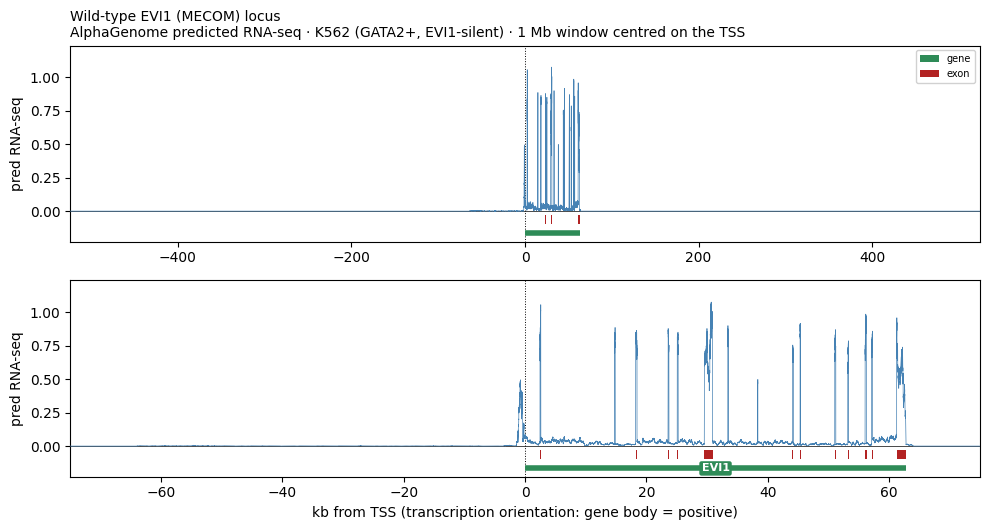

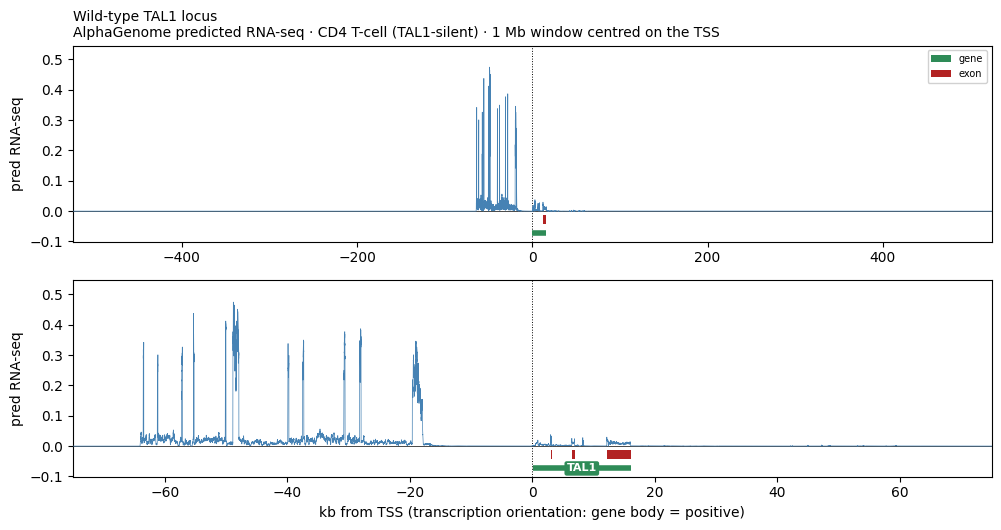

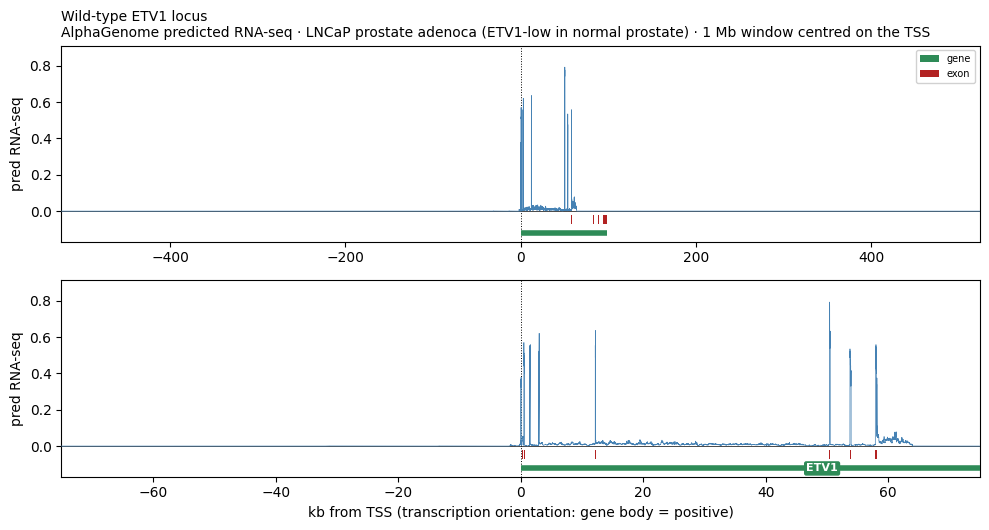

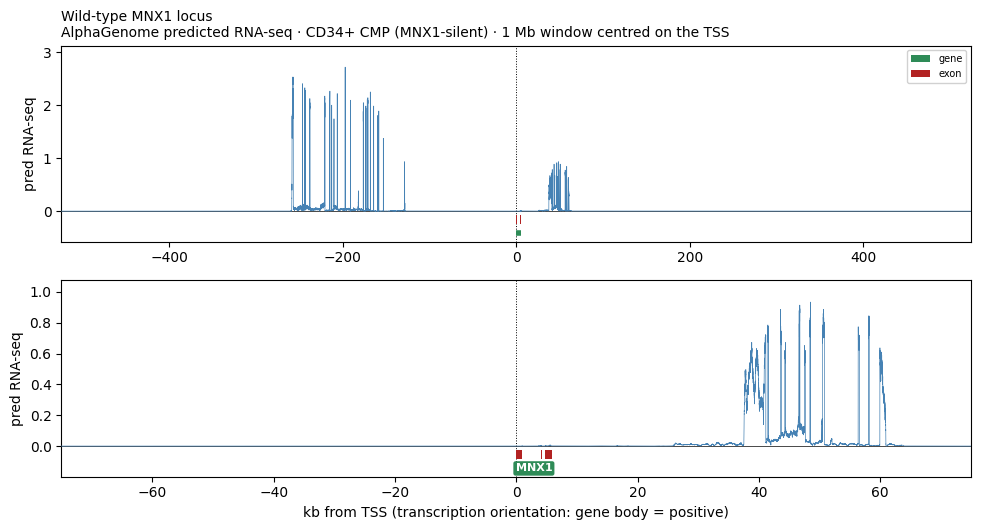

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_locus(gene, track, tss, strand, exon_list, title, desc, enh=None):
    flip = -1 if strand == '-' else 1                        # transcription orientation: gene body -> +x
    x = flip * (np.arange(W) - W // 2) / 1000                # kb from TSS
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))   # gene-of-interest body

    fig, (over, detail) = plt.subplots(2, 1, figsize=(10, 5.4))
    for ax, half in [(over, W // 2 / 1000), (detail, 75)]:
        vis = np.abs(x) <= half
        ymax = max(float(track[vis].max()) * 1.15, 1e-4)
        eh = ymax * 0.05
        ax.plot(x, track, lw=0.5, color='steelblue', zorder=3)                  # RNA-seq on top
        ax.axhline(0, color='k', lw=0.5, zorder=2)
        ax.axvline(0, color='k', ls=':', lw=0.7, zorder=2)
        for s, e in exon_list:                                                  # exons: red, on the annotation row
            a, b = span(s, e)
            ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                       color='firebrick', lw=0, zorder=5, clip_on=True))
        if enh is not None:                                                     # enhancer: orange, same row as exons
            ex0, ex1 = span(*enh)
            if ex1 >= -half and ex0 <= half:
                ax.add_patch(plt.Rectangle((max(ex0, -half), -1.5 * eh), min(ex1, half) - max(ex0, -half), eh,
                                           color='darkorange', lw=0, zorder=6, clip_on=True))
        ax.plot([max(ga, -half), min(gb, half)], [-2.7 * eh, -2.7 * eh],        # gene: green track below exons
                lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
        if half <= 75:
            ax.text(np.clip((ga + gb) / 2, -half, half), -2.7 * eh, gene.split()[0],
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
        ax.set_xlim(-half, half)
        ax.set_ylim(-3.7 * eh, ymax)
        ax.set_ylabel('pred RNA-seq')

    handles = [Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    if enh is not None:
        handles.append(Patch(facecolor='darkorange', label='enhancer'))
    over.legend(handles=handles, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    over.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    detail.set_xlabel('kb from TSS (transcription orientation: gene body = positive)')
    fig.tight_layout()

for r in wildtypes.itertuples():
    plot_locus(r.driven_gene, r.rna_track, int(r.onco_tss), r.strand, exons[r.driven_gene],
               f"Wild-type {r.driven_gene} locus",
               f"AlphaGenome predicted RNA-seq · {r.cell_context} · 1 Mb window centred on the TSS")

### Reading the WT baselines

Oncogene silent in its cell type → its own exons flat; in-window peaks are neighbours, not the target. That's the expected baseline. Capture (in der) = new signal on the target's own exons. EVI1 is the exception — low-but-present in K562.

- EVI1 / K562 — low-but-present; K562 not EVI1-rearranged (Gröschel, Cell 2014, PMID 24703711).
- TAL1 / CD4 T — silent; HPA "not detected in immune cells"; peaks = STIL (Mansour, Science 2014, PMID 25394790).
- ETV1 / LNCaP — low in normal prostate, ON in LNCaP (replaces LMO2; Wang, Nat Methods 2021, PMID 34092790).
- MNX1 / CD34 — silent; the +35–65 kb peak = NOM1 (Naranjo, Blood Adv 2024, PMID 39121370).

RNA seq readings check out and are expected for WT.

## TSS-centered der

Predict RNA-seq on each der (enhancer transplanted near the oncogene TSS), plotted **on its own** — same readout and style as the WT panels. Overlay vs WT + a marker for where the enhancer was inserted come in the next step.

In [8]:
# the TSS-centered der constructs (enhancer transplanted); EGFR has no enhancer-hijacking der here
ders = tss_centered.dropna(subset=['onco_tss', 'element_len']).reset_index(drop=True).copy()
ders['onco_tss'] = ders['onco_tss'].astype(int)
ders['rna_track'] = [predict_rna(r.der_seq, r.ontology, r.strand) for r in ders.itertuples()]

def _enh_span(wt, der, tss):   # genomic span of the inserted element = where der differs from WT
    d = np.where(np.frombuffer(wt.encode(), 'S1') != np.frombuffer(der.encode(), 'S1'))[0]
    return (tss - W // 2 + int(d[0]), tss - W // 2 + int(d[-1]) + 1) if len(d) else None
ders['enh_span'] = [_enh_span(r.wt_seq, r.der_seq, r.onco_tss) for r in ders.itertuples()]

ders[['name', 'driven_gene', 'enhancer', 'insert_kb_from_TSS']]

,name,driven_gene,enhancer,insert_kb_from_TSS
0,GATA2-MECOM,EVI1 (MECOM),G2DHE (GATA2 distal enhancer),10.0
1,TCR-TAL1,TAL1,TCRδ (Eδ) enhancer,10.0
2,MIPOL1-ETV1,ETV1,chr14q13 enhancer (MIPOL1-intronic; M2 DNase p...,10.0
3,ETV6-MNX1@10kb,MNX1,ETV6-region hematopoietic enhancer block,10.0
4,ETV6-MNX1@30kb,MNX1,ETV6-region hematopoietic enhancer block,30.0
5,ETV6-MNX1@60kb,MNX1,ETV6-region hematopoietic enhancer block,60.0
6,ETV6-MNX1@100kb,MNX1,ETV6-region hematopoietic enhancer block,100.0


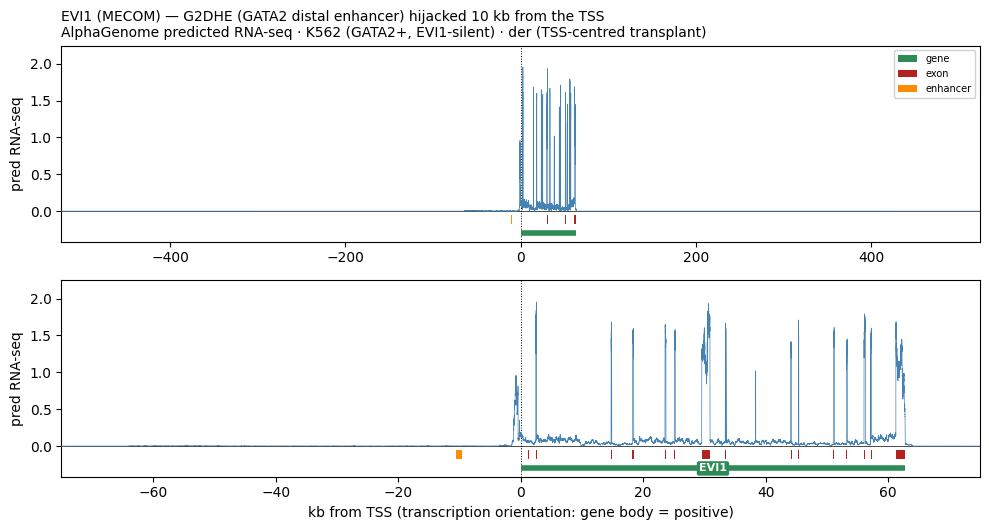

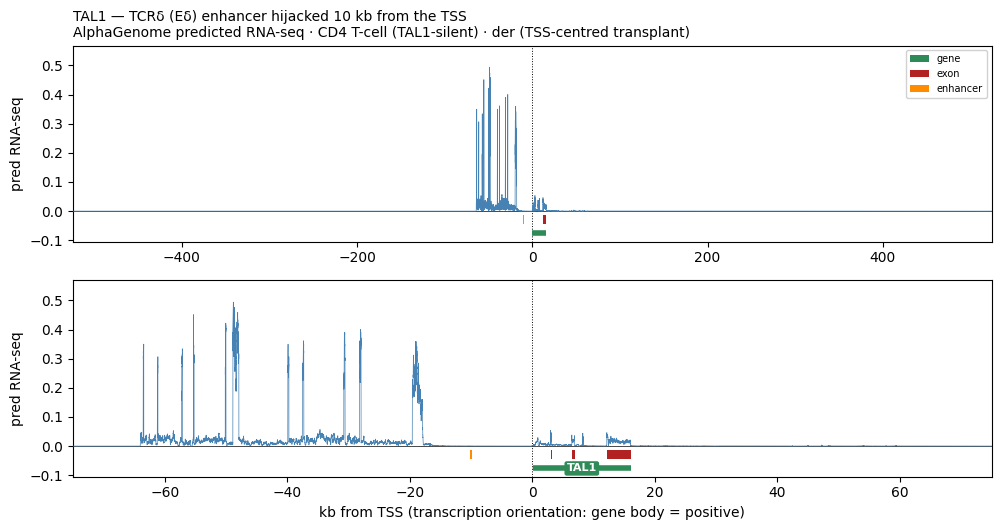

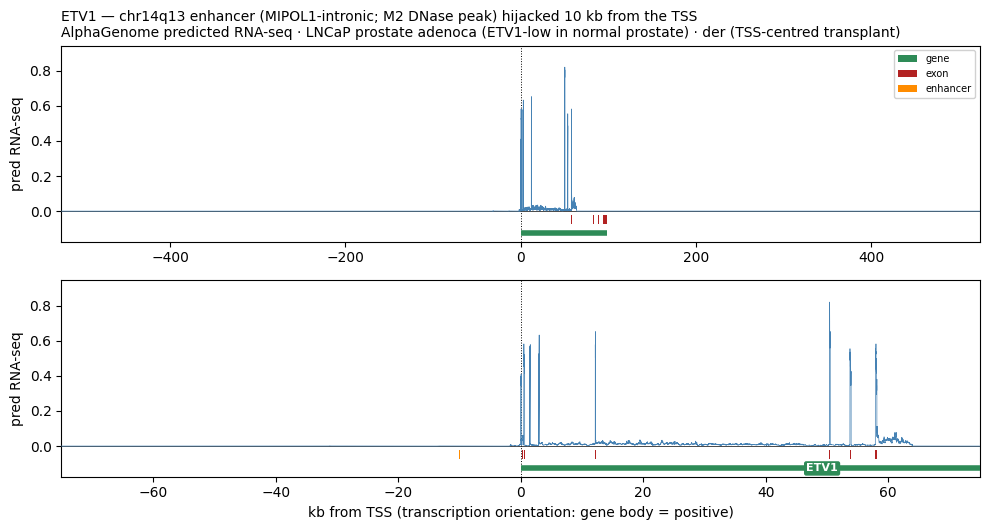

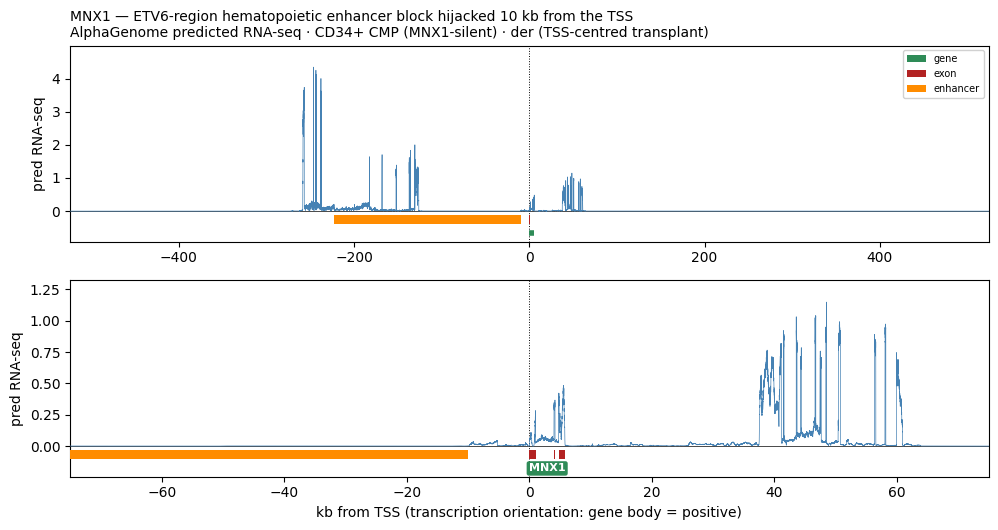

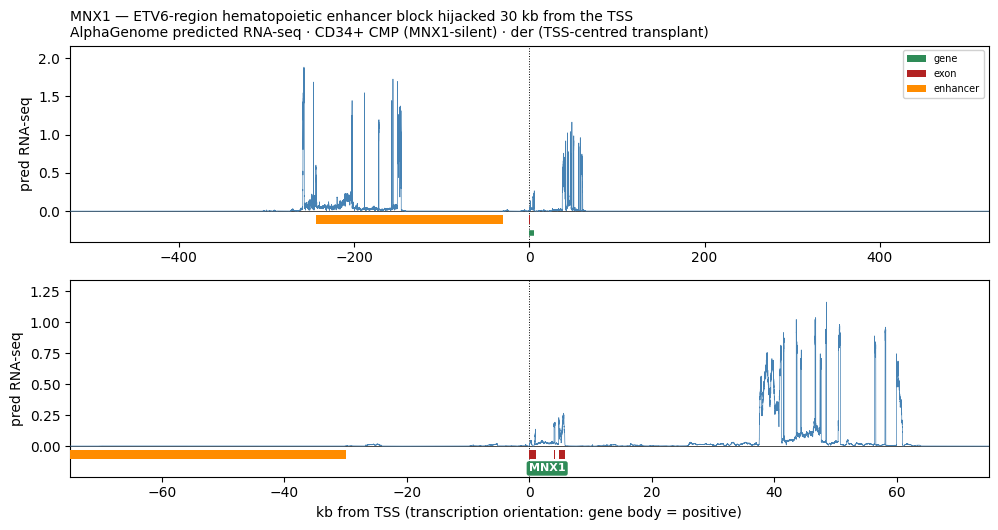

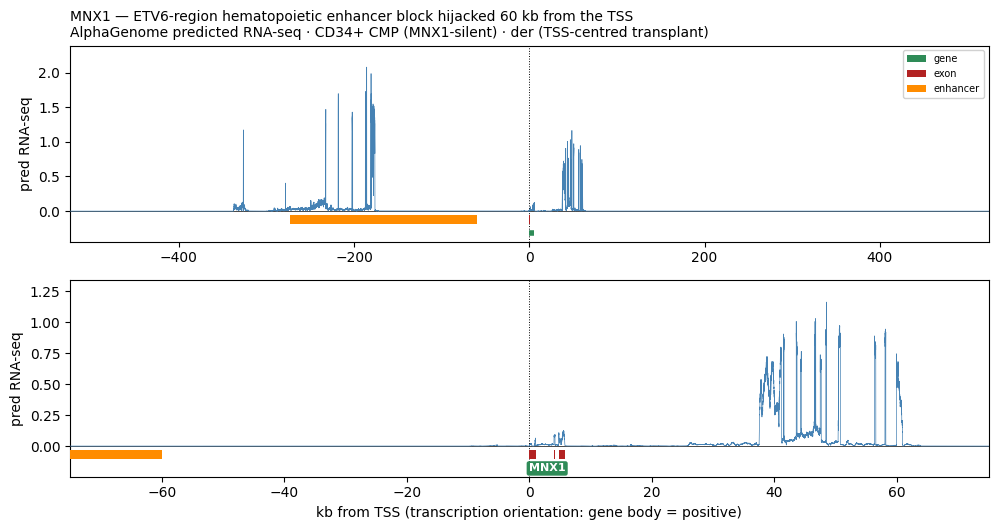

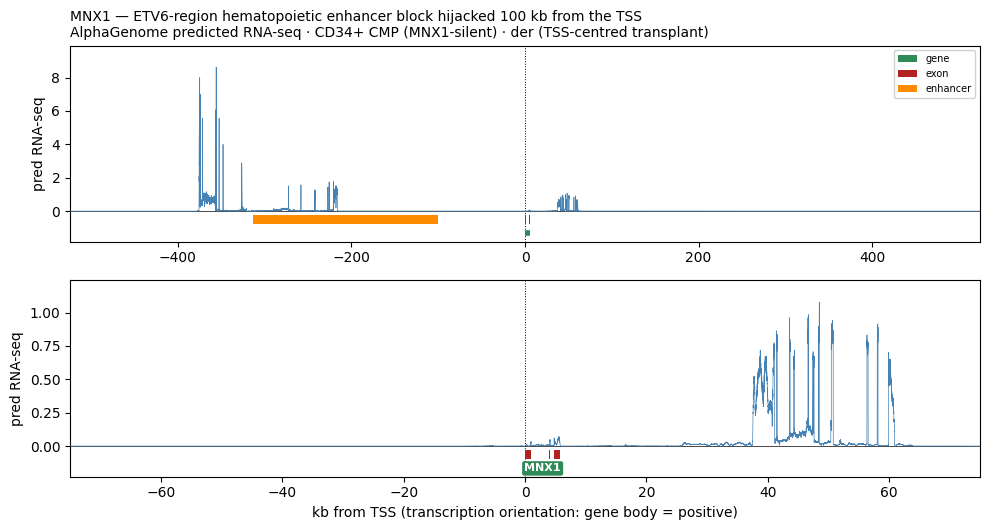

In [9]:
for r in ders.itertuples():
    plot_locus(r.driven_gene, r.rna_track, r.onco_tss, r.strand, exons[r.driven_gene],
               f"{r.driven_gene} — {r.enhancer} hijacked {r.insert_kb_from_TSS:.0f} kb from the TSS",
               f"AlphaGenome predicted RNA-seq · {r.cell_context} · der (TSS-centred transplant)",
               enh=r.enh_span)

## WT vs der overlay

WT (pink) and der (blue) on shared axes, so the change is read directly — der gaining signal on the gene's **own exons** is capture. Same exon / gene / enhancer annotation and legend as above.

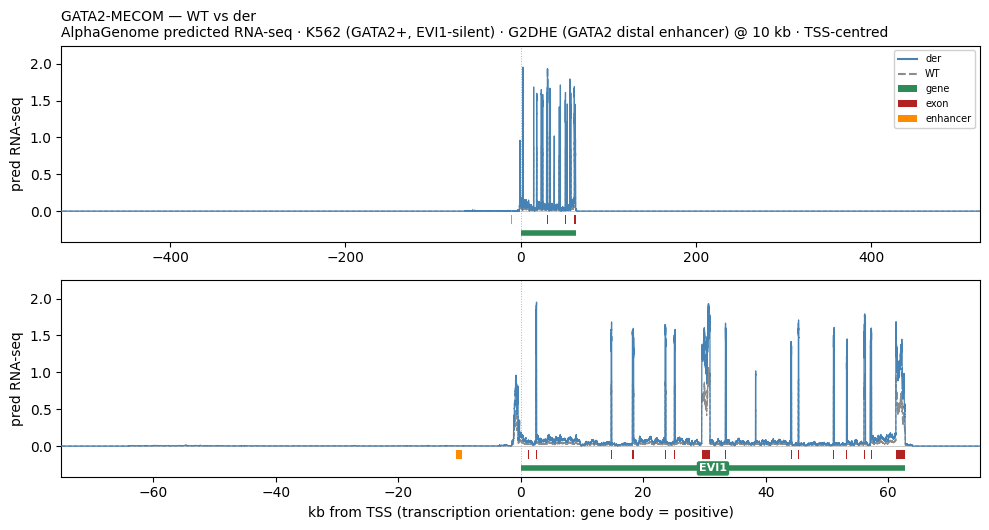

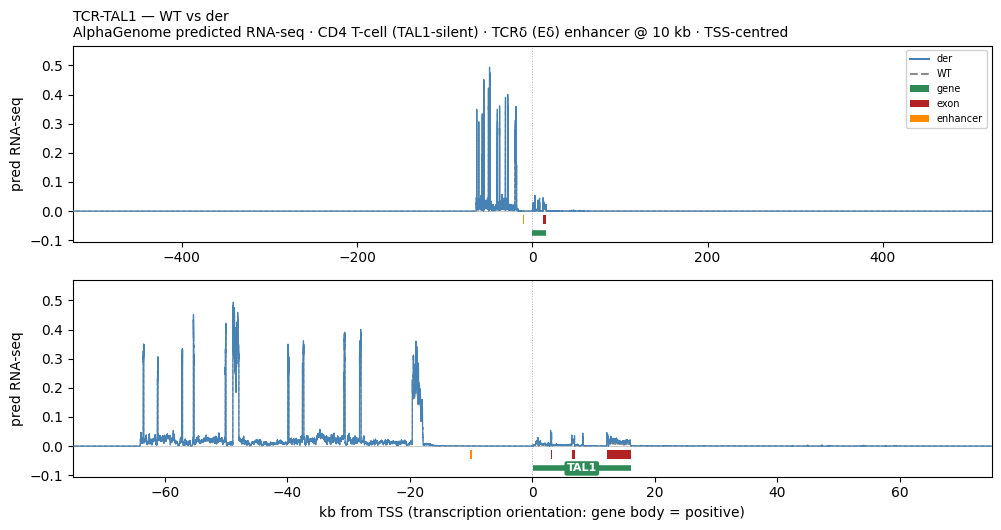

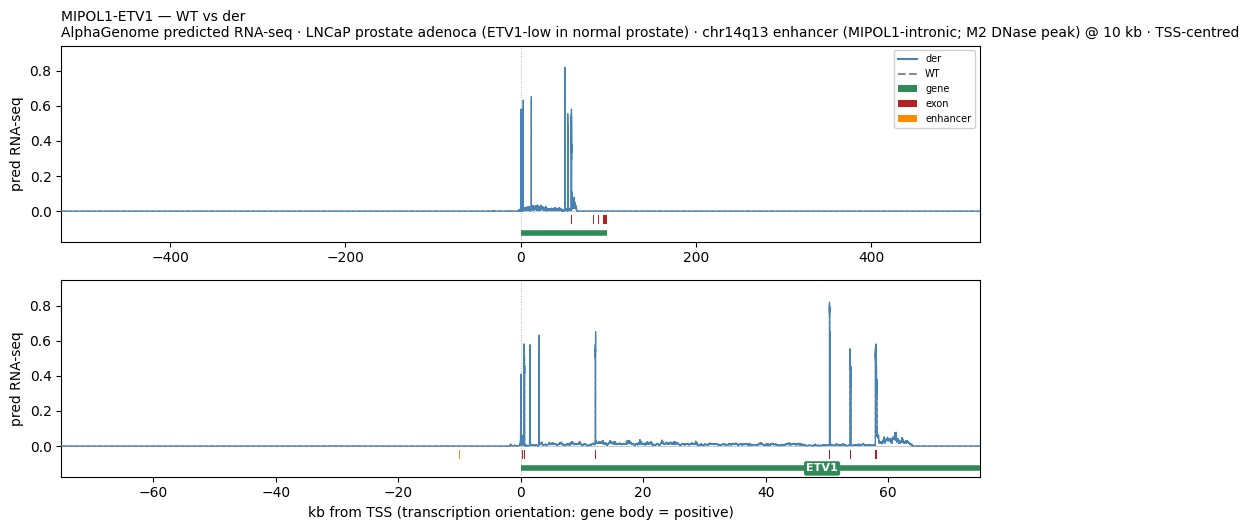

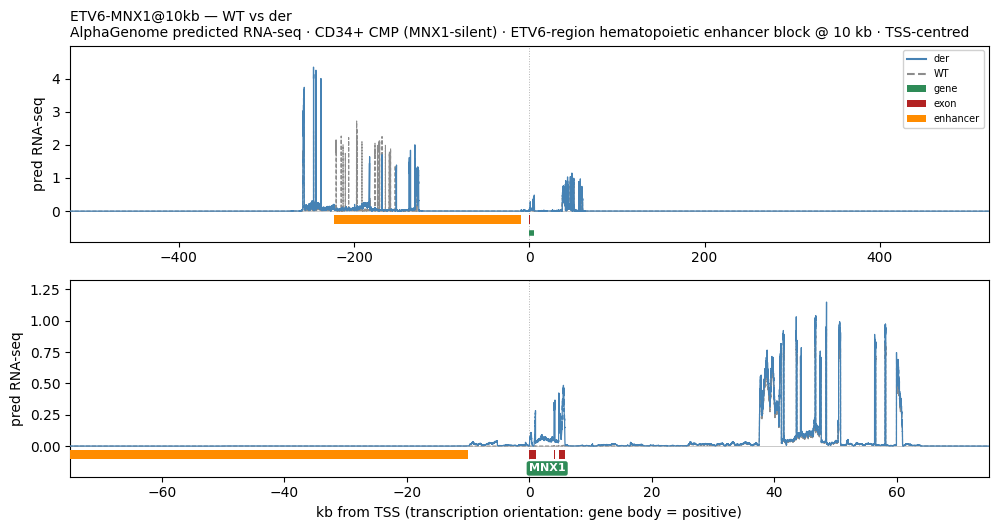

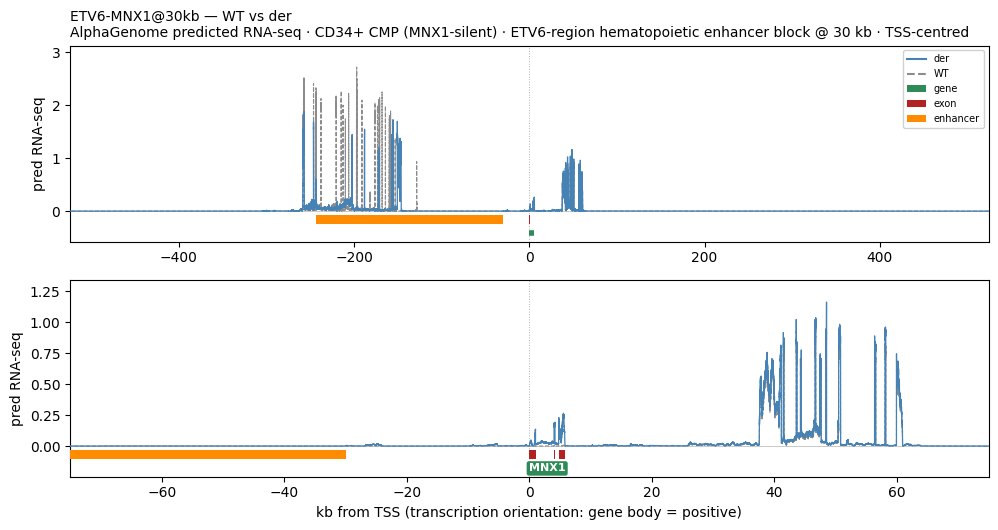

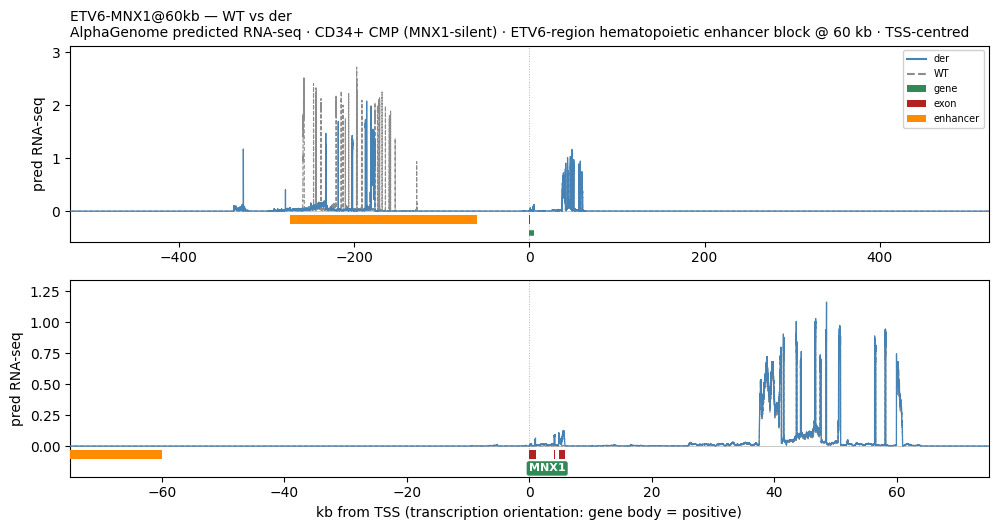

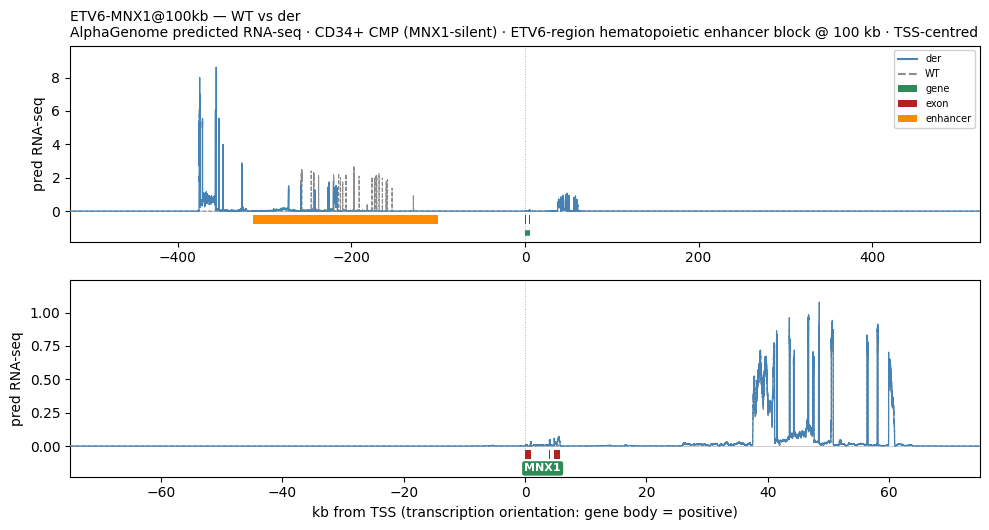

In [10]:
from matplotlib.lines import Line2D

def plot_overlay(gene, wt, der, tss, strand, exon_list, title, desc, enh=None):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - W // 2) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))

    fig, (over, detail) = plt.subplots(2, 1, figsize=(10, 5.4))
    for ax, half in [(over, W // 2 / 1000), (detail, 75)]:
        vis = np.abs(x) <= half
        ymax = max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4)      # shared y across WT and der
        eh = ymax * 0.05
        ax.plot(x, wt,  lw=0.8, color='0.55', ls='--', zorder=3)                # WT  = gray dashed
        ax.plot(x, der, lw=0.9, color='steelblue', zorder=4)                    # der = light blue
        ax.axhline(0, color='0.7', lw=0.5, zorder=2)
        ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
        for s, e in exon_list:
            a, b = span(s, e)
            ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                       color='firebrick', lw=0, zorder=5, clip_on=True))
        if enh is not None:
            ex0, ex1 = span(*enh)
            if ex1 >= -half and ex0 <= half:
                ax.add_patch(plt.Rectangle((max(ex0, -half), -1.5 * eh), min(ex1, half) - max(ex0, -half), eh,
                                           color='darkorange', lw=0, zorder=6, clip_on=True))
        ax.plot([max(ga, -half), min(gb, half)], [-2.7 * eh, -2.7 * eh],
                lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
        if half <= 75:
            ax.text(np.clip((ga + gb) / 2, -half, half), -2.7 * eh, gene.split()[0],
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
        ax.set_xlim(-half, half)
        ax.set_ylim(-3.7 * eh, ymax)
        ax.set_ylabel('pred RNA-seq')

    handles = [Line2D([0], [0], color='steelblue', lw=1.5, label='der'),
               Line2D([0], [0], color='0.55', lw=1.5, ls='--', label='WT'),
               Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    if enh is not None:
        handles.append(Patch(facecolor='darkorange', label='enhancer'))
    over.legend(handles=handles, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    over.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    detail.set_xlabel('kb from TSS (transcription orientation: gene body = positive)')
    fig.tight_layout()

wt_by_gene = dict(zip(wildtypes['driven_gene'], wildtypes['rna_track']))
for r in ders.itertuples():
    plot_overlay(r.driven_gene, wt_by_gene[r.driven_gene], r.rna_track, r.onco_tss, r.strand, exons[r.driven_gene],
                 f"{r.name} — WT vs der",
                 f"AlphaGenome predicted RNA-seq · {r.cell_context} · {r.enhancer} @ {r.insert_kb_from_TSS:.0f} kb · TSS-centred",
                 enh=r.enh_span)

## Gene close-up (WT vs der)

The same overlay zoomed to the gene body ±10 kb — the cleanest view of der (pink) gaining RNA on the gene's **own exons** versus WT (blue).

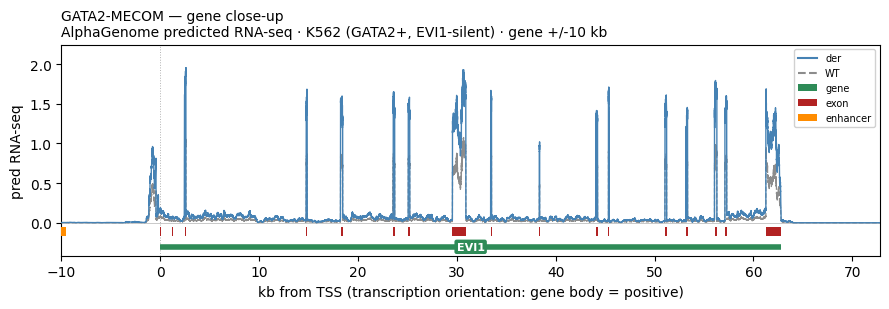

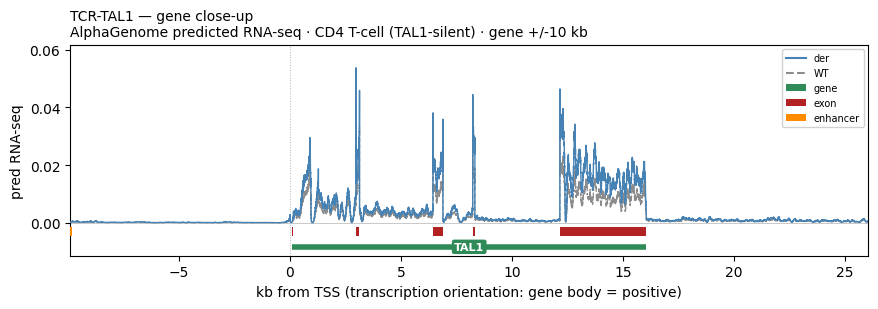

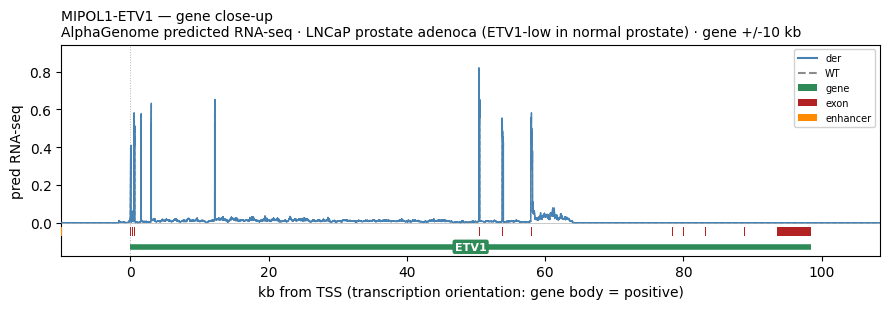

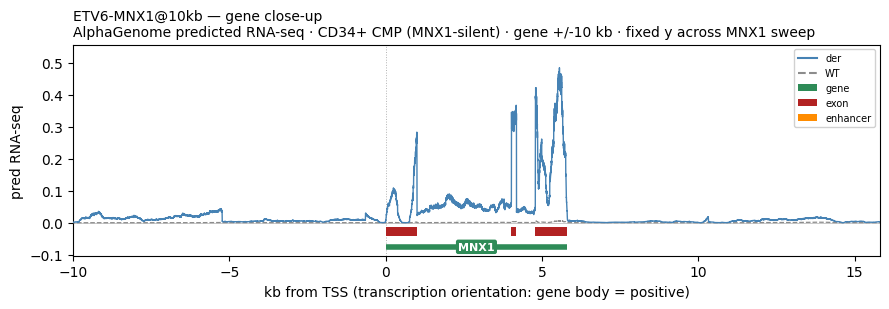

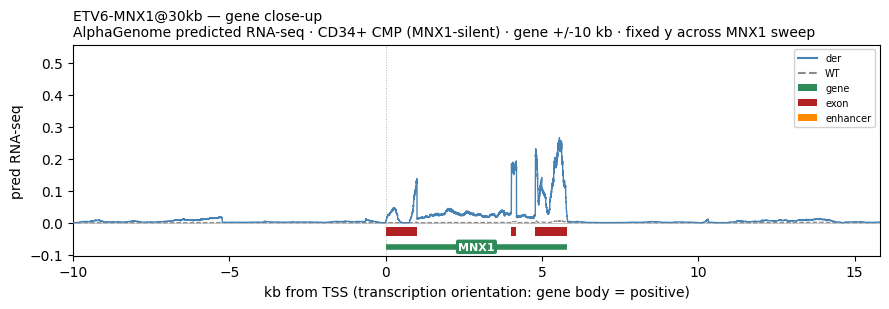

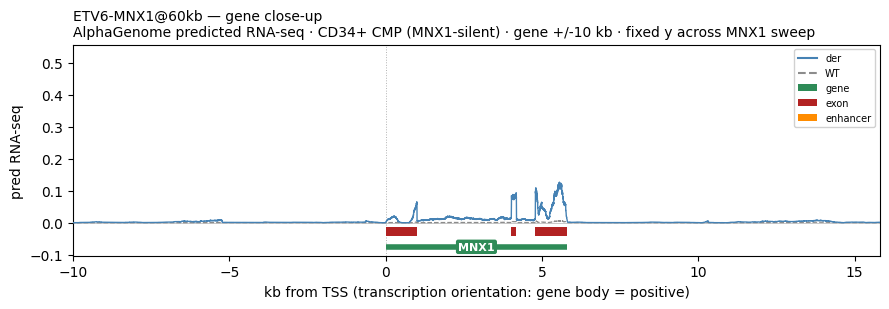

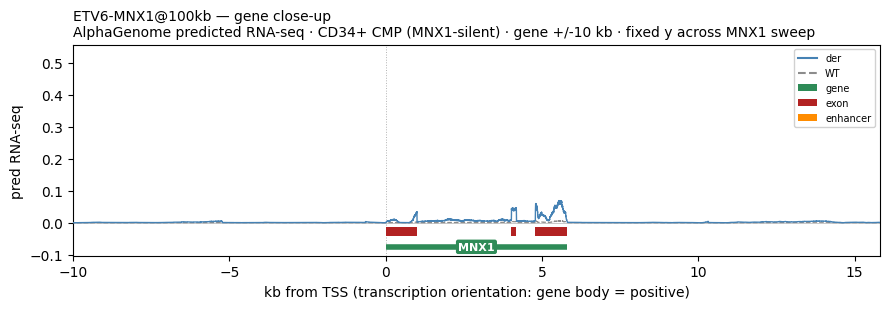

In [11]:
def plot_genezoom(gene, wt, der, tss, strand, exon_list, title, desc, enh=None, pad_kb=10, ymax_fixed=None):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - W // 2) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    lo, hi = ga - pad_kb, gb + pad_kb                        # gene body +/- pad_kb
    vis = (x >= lo) & (x <= hi)
    ymax = ymax_fixed if ymax_fixed is not None else max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4)
    eh = ymax * 0.05

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(x, wt,  lw=0.9, color='0.55', ls='--', zorder=3)                    # WT  = gray dashed
    ax.plot(x, der, lw=1.0, color='steelblue', zorder=4)                        # der = light blue
    ax.axhline(0, color='0.7', lw=0.5, zorder=2)
    ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
    for s, e in exon_list:
        a, b = span(s, e)
        ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                   color='firebrick', lw=0, zorder=5, clip_on=True))
    if enh is not None:
        ex0, ex1 = span(*enh)
        if ex1 >= lo and ex0 <= hi:
            ax.add_patch(plt.Rectangle((max(ex0, lo), -1.5 * eh), min(ex1, hi) - max(ex0, lo), eh,
                                       color='darkorange', lw=0, zorder=6, clip_on=True))
    ax.plot([max(ga, lo), min(gb, hi)], [-2.7 * eh, -2.7 * eh],
            lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
    ax.text(np.clip((ga + gb) / 2, lo, hi), -2.7 * eh, gene.split()[0],
            ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
    ax.set_xlim(lo, hi)
    ax.set_ylim(-3.7 * eh, ymax)
    ax.set_ylabel('pred RNA-seq')
    ax.set_xlabel('kb from TSS (transcription orientation: gene body = positive)')

    handles = [Line2D([0], [0], color='steelblue', lw=1.5, label='der'),
               Line2D([0], [0], color='0.55', lw=1.5, ls='--', label='WT'),
               Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    if enh is not None:
        handles.append(Patch(facecolor='darkorange', label='enhancer'))
    ax.legend(handles=handles, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    ax.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    fig.tight_layout()

# common y for the MNX1 distance-sweep close-ups, so the der signal visibly DECAYS with distance
def _gene_winmax(track, tss, strand, exon_list, pad_kb=10):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - W // 2) / 1000
    sp = sorted((flip * (min(s for s, e in exon_list) - tss) / 1000,
                 flip * (max(e for s, e in exon_list) - tss) / 1000))
    return float(track[(x >= sp[0] - pad_kb) & (x <= sp[1] + pad_kb)].max())

mnx = ders[ders.driven_gene == 'MNX1']
mnx_ymax = (max(_gene_winmax(r.rna_track, r.onco_tss, r.strand, exons[r.driven_gene]) for r in mnx.itertuples()) * 1.15
            if len(mnx) else None)

for r in ders.itertuples():
    fixed = mnx_ymax if r.driven_gene == 'MNX1' else None
    plot_genezoom(r.driven_gene, wt_by_gene[r.driven_gene], r.rna_track, r.onco_tss, r.strand, exons[r.driven_gene],
                  f"{r.name} — gene close-up",
                  f"AlphaGenome predicted RNA-seq · {r.cell_context} · gene +/-10 kb"
                  + (" · fixed y across MNX1 sweep" if r.driven_gene == 'MNX1' else ""),
                  enh=r.enh_span, ymax_fixed=fixed)

## Specificity control — scrambled enhancer

Re-insert each enhancer **dinucleotide-shuffled** (same composition/CpG, motifs destroyed) at the same position; saved as `scrambled`. Two pairwise views per construct:
- **scrambled vs WT** — is the scrambled enhancer inert (back at baseline)?
- **scrambled vs der (real)** — does the real enhancer beat the scramble?

Enhancer-specific capture = scrambled ≈ WT **and** der (real) ≫ scrambled.

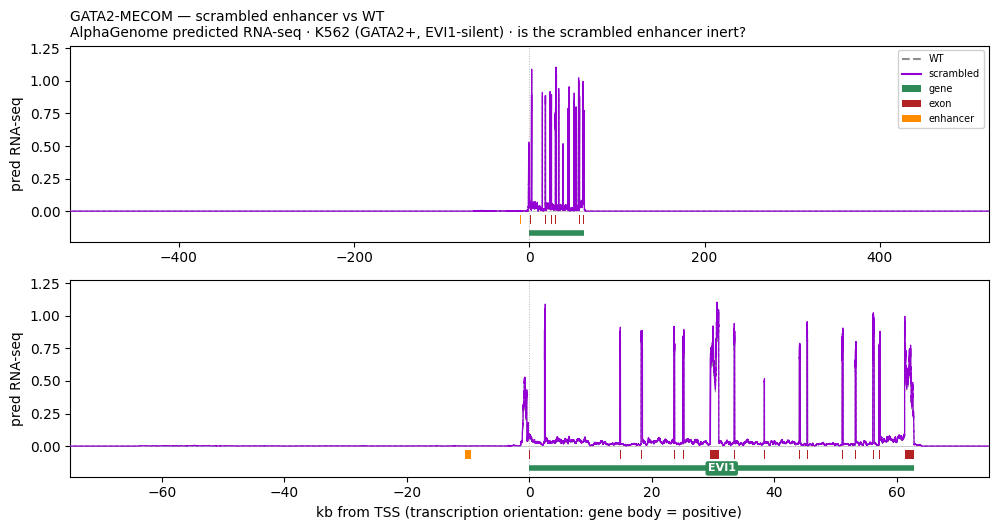

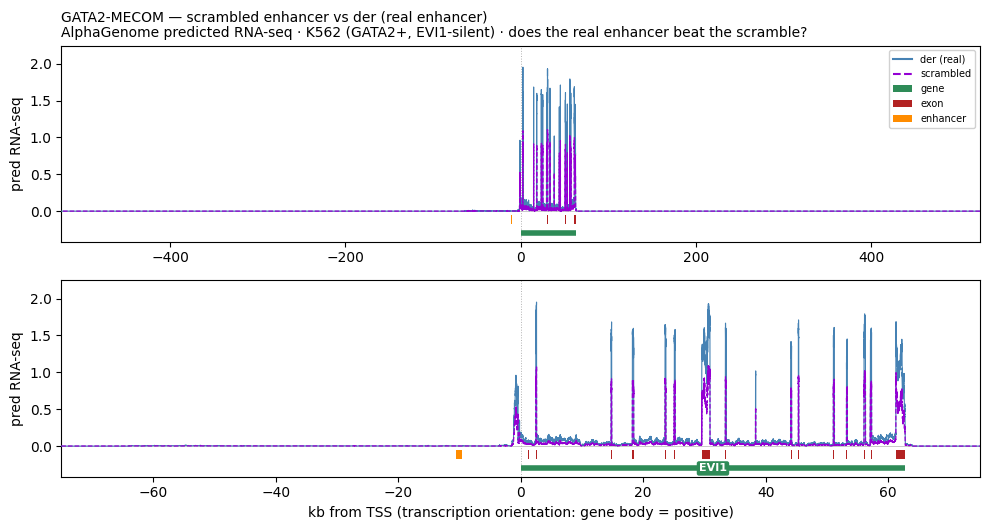

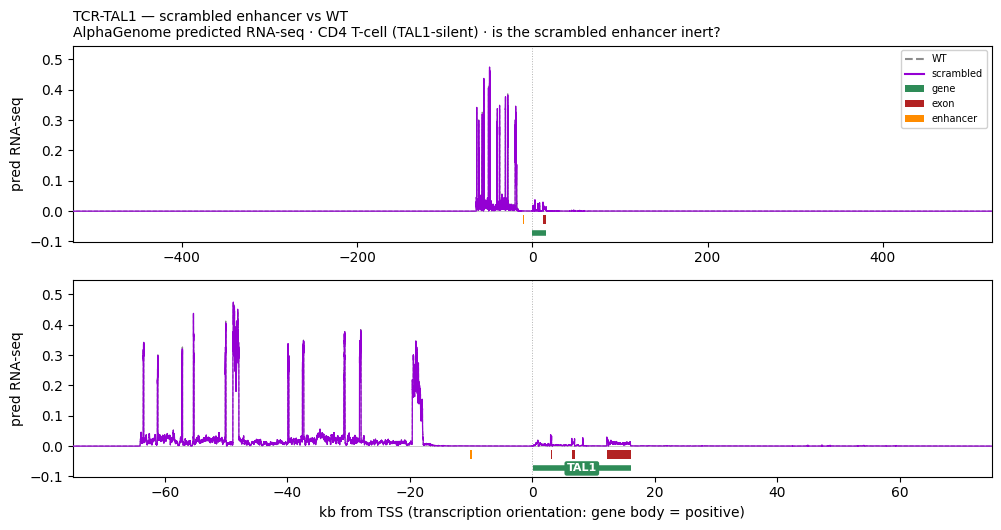

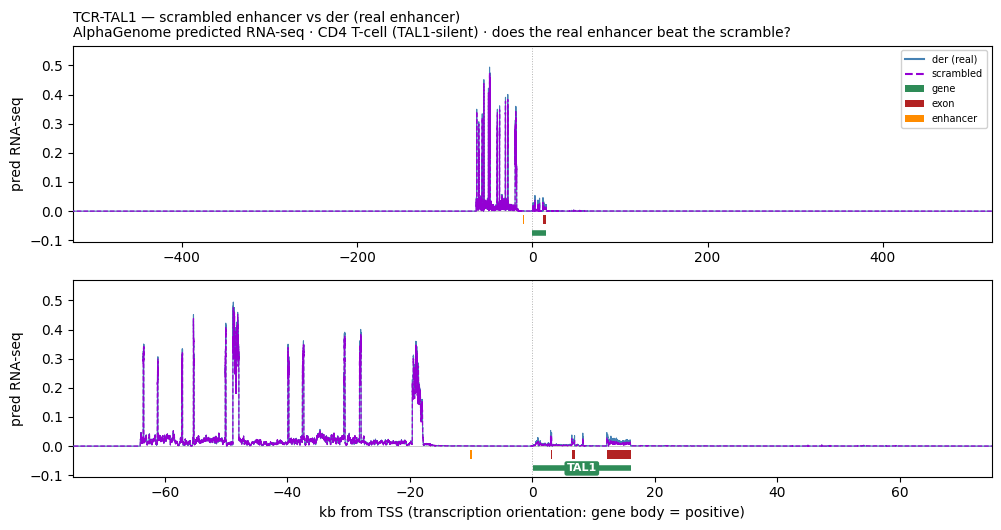

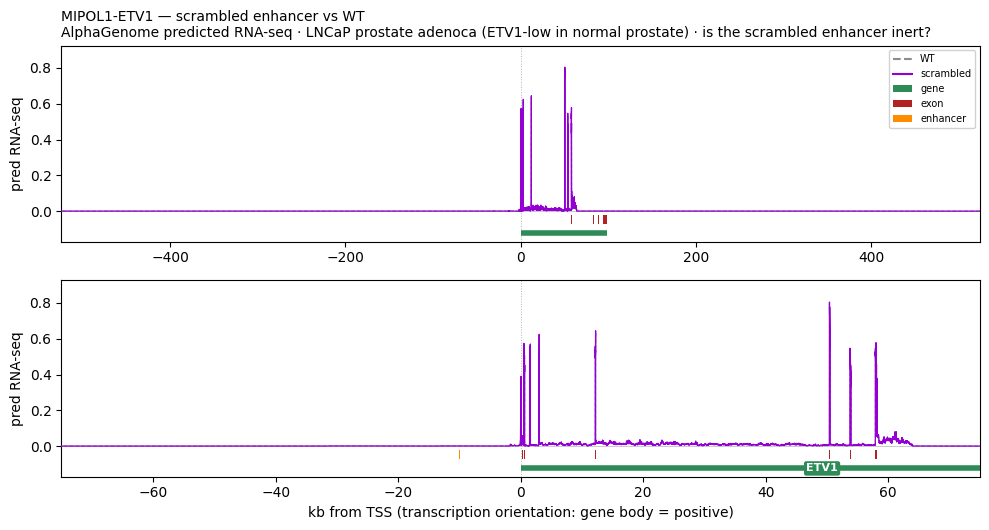

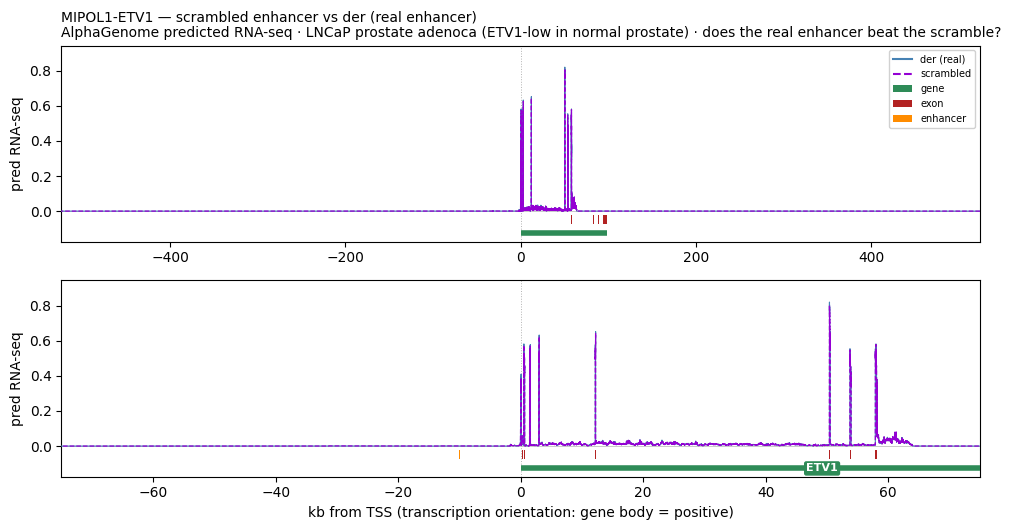

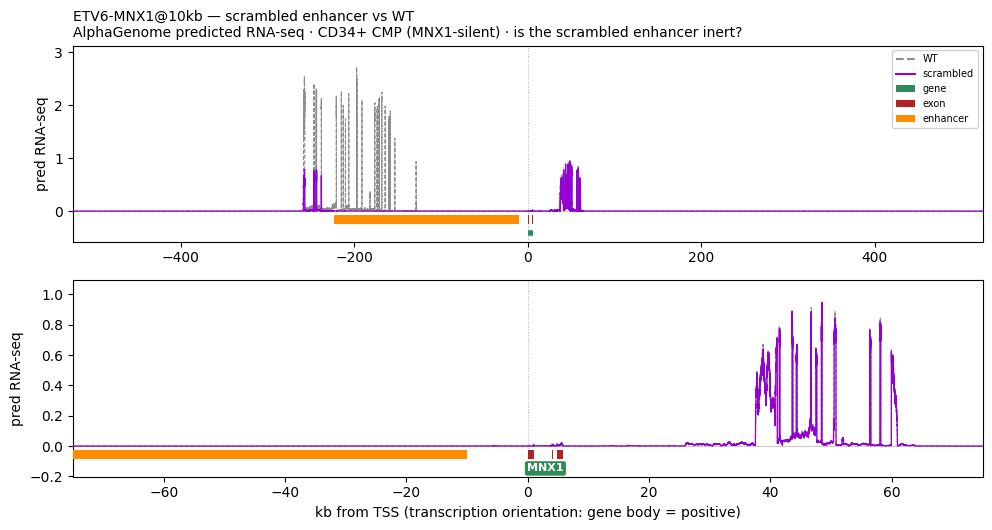

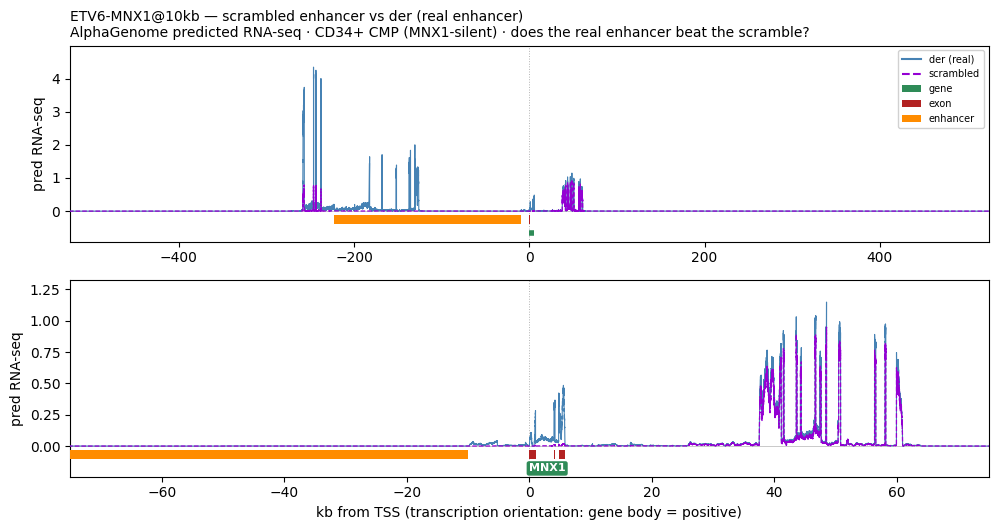

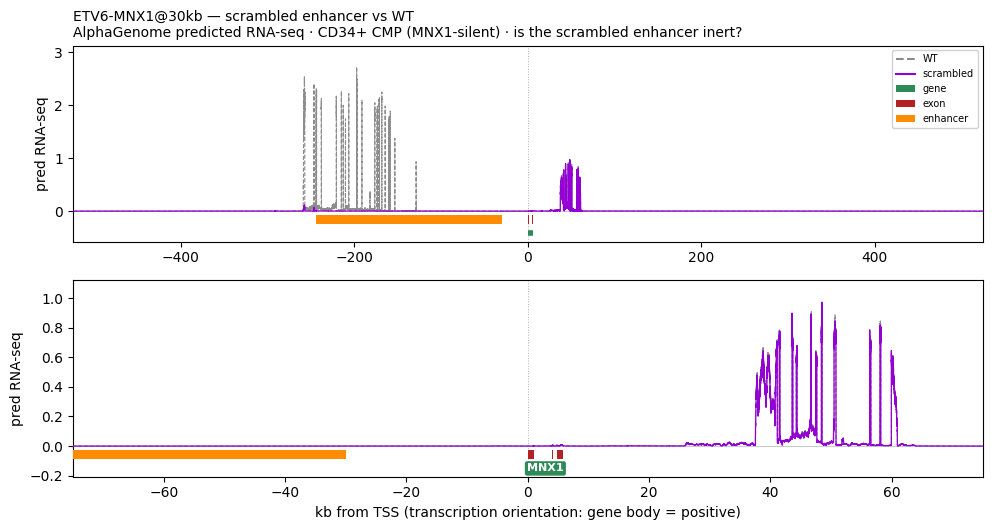

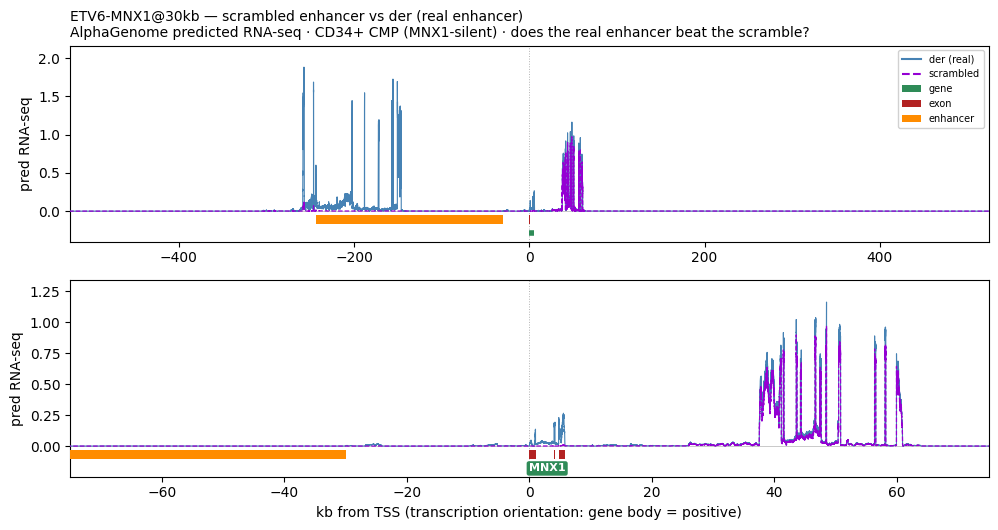

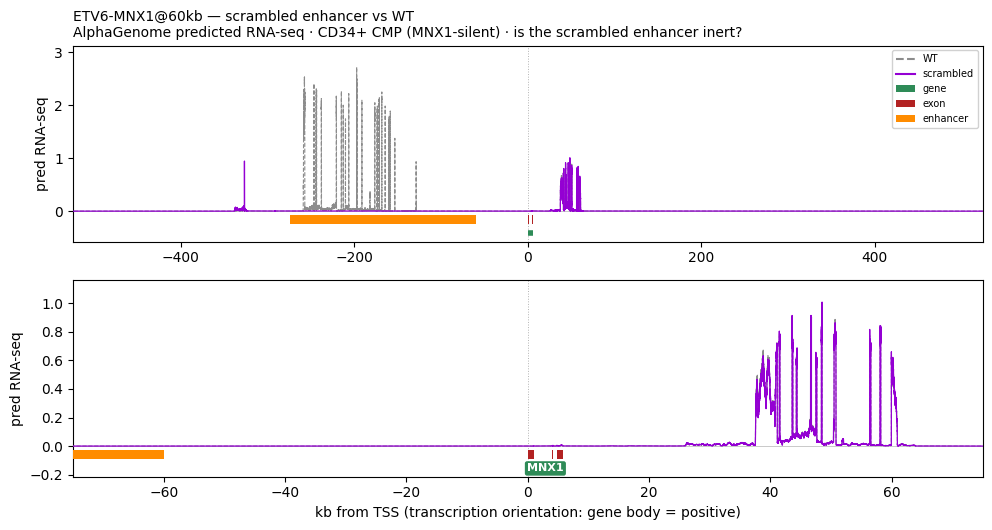

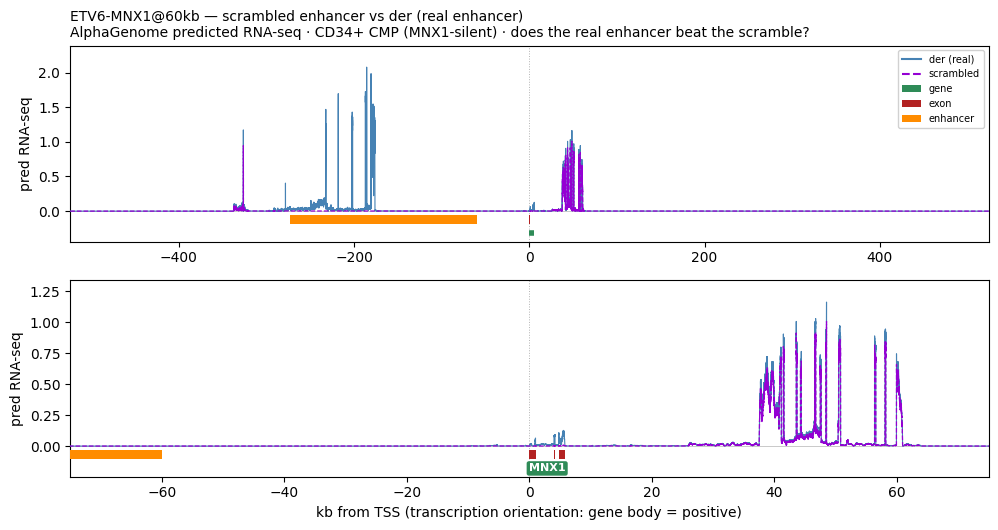

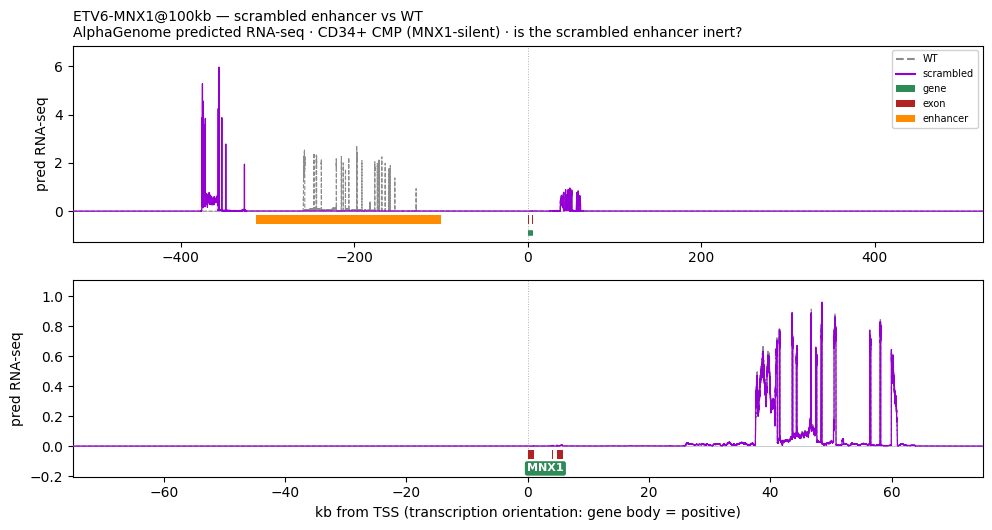

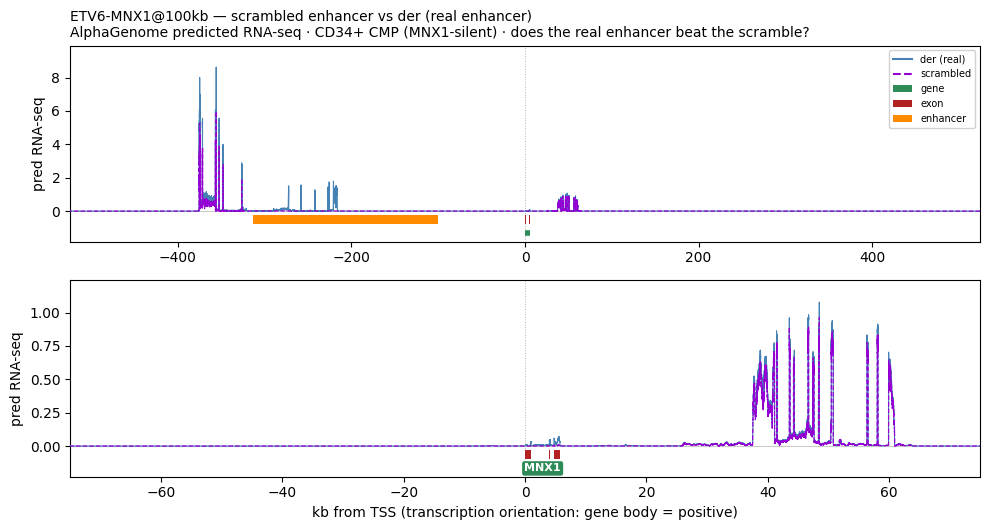

In [12]:
from fusionseq import motifs

# specificity control: re-insert each enhancer DINUCLEOTIDE-shuffled (composition/CpG kept, motifs destroyed)
def _scramble(der_seq, enh_span, tss, seed=0):
    off = enh_span[0] - (tss - W // 2); w = enh_span[1] - enh_span[0]
    shuf = motifs.dinuc_shuffle(der_seq[off:off + w], np.random.default_rng(seed))
    return der_seq[:off] + shuf + der_seq[off + w:]

scrambled = ders.copy()
scrambled['der_seq']   = [_scramble(r.der_seq, r.enh_span, r.onco_tss) for r in ders.itertuples()]
scrambled['rna_track'] = [predict_rna(r.der_seq, r.ontology, r.strand) for r in scrambled.itertuples()]
shuf_by_name = dict(zip(scrambled['name'], scrambled['rna_track']))

def plot_pair(gene, ta, tb, la, lb, ca, cb, lsa, lsb, tss, strand, exon_list, title, desc, enh=None):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - W // 2) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    fig, (over, detail) = plt.subplots(2, 1, figsize=(10, 5.4))
    for ax, half in [(over, W // 2 / 1000), (detail, 75)]:
        vis = np.abs(x) <= half
        ymax = max(float(max(ta[vis].max(), tb[vis].max())) * 1.15, 1e-4)       # shared y
        eh = ymax * 0.05
        ax.plot(x, ta, lw=0.8, color=ca, ls=lsa, zorder=3)
        ax.plot(x, tb, lw=0.9, color=cb, ls=lsb, zorder=4)
        ax.axhline(0, color='0.7', lw=0.5, zorder=2)
        ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
        for s, e in exon_list:
            a, b = span(s, e)
            ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                       color='firebrick', lw=0, zorder=5, clip_on=True))
        if enh is not None:
            ex0, ex1 = span(*enh)
            if ex1 >= -half and ex0 <= half:
                ax.add_patch(plt.Rectangle((max(ex0, -half), -1.5 * eh), min(ex1, half) - max(ex0, -half), eh,
                                           color='darkorange', lw=0, zorder=6, clip_on=True))
        ax.plot([max(ga, -half), min(gb, half)], [-2.7 * eh, -2.7 * eh],
                lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
        if half <= 75:
            ax.text(np.clip((ga + gb) / 2, -half, half), -2.7 * eh, gene.split()[0],
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
        ax.set_xlim(-half, half)
        ax.set_ylim(-3.7 * eh, ymax)
        ax.set_ylabel('pred RNA-seq')
    handles = [Line2D([0], [0], color=ca, lw=1.5, ls=lsa, label=la),
               Line2D([0], [0], color=cb, lw=1.5, ls=lsb, label=lb),
               Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    if enh is not None:
        handles.append(Patch(facecolor='darkorange', label='enhancer'))
    over.legend(handles=handles, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    over.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    detail.set_xlabel('kb from TSS (transcription orientation: gene body = positive)')
    fig.tight_layout()

for r in ders.itertuples():
    shuf = shuf_by_name[r.name]
    plot_pair(r.driven_gene, wt_by_gene[r.driven_gene], shuf, 'WT', 'scrambled',
              '0.55', 'darkviolet', '--', '-', r.onco_tss, r.strand, exons[r.driven_gene],
              f"{r.name} — scrambled enhancer vs WT",
              f"AlphaGenome predicted RNA-seq · {r.cell_context} · is the scrambled enhancer inert?",
              enh=r.enh_span)
    plot_pair(r.driven_gene, r.rna_track, shuf, 'der (real)', 'scrambled',
              'steelblue', 'darkviolet', '-', '--', r.onco_tss, r.strand, exons[r.driven_gene],
              f"{r.name} — scrambled enhancer vs der (real enhancer)",
              f"AlphaGenome predicted RNA-seq · {r.cell_context} · does the real enhancer beat the scramble?",
              enh=r.enh_span)